In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

In [2]:
from google.colab import files
files.upload()
df = pd.read_csv("blinkit_data.csv")

Saving blinkit_data.csv to blinkit_data.csv


In [3]:
df = pd.read_csv("blinkit_data.csv")

In [4]:
df.head(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [5]:
df.shape

(8523, 12)

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [8]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [9]:
df=df.replace({"LF":"Low Fat",
              "reg":"Regular",
               "low fat":"Low Fat"})

In [10]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


In [12]:
total_sales=df["Sales"].sum()
rage_sales=df["Sales"].mean()
no_of_items_sold=df["Sales"].count()
avg_rating=df["Rating"].mean()
print("total_sales:",total_sales)

total_sales: 1201681.4808


In [13]:
average_sales=df["Sales"].mean()
average_sales

np.float64(140.9927819781767)

In [14]:
no_of_items_sold=df["Sales"].count()
print(no_of_items_sold)

8523


In [15]:
avg_rating=df["Rating"].mean()
print("avg_rating:",avg_rating)

avg_rating: 3.965857092573038


**SALES BY ITEM FAT  CONTENT**

Item Fat Content
Low Fat    776319.6784
Regular    425361.8024
Name: Sales, dtype: float64


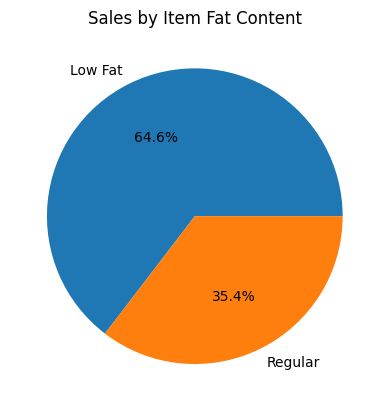

In [16]:
sales_by_fat=df.groupby("Item Fat Content")["Sales"].sum()
print(sales_by_fat)
plt.pie(sales_by_fat,labels=sales_by_fat.index, autopct='%1.1f%%')
plt.title('Sales by Item Fat Content')
plt.show()

**SALES BY ITEM TYPE**

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9204
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4596
Canned                    90706.7270
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1650
Breads                    35379.1198
Hard Drinks               29334.6766
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64


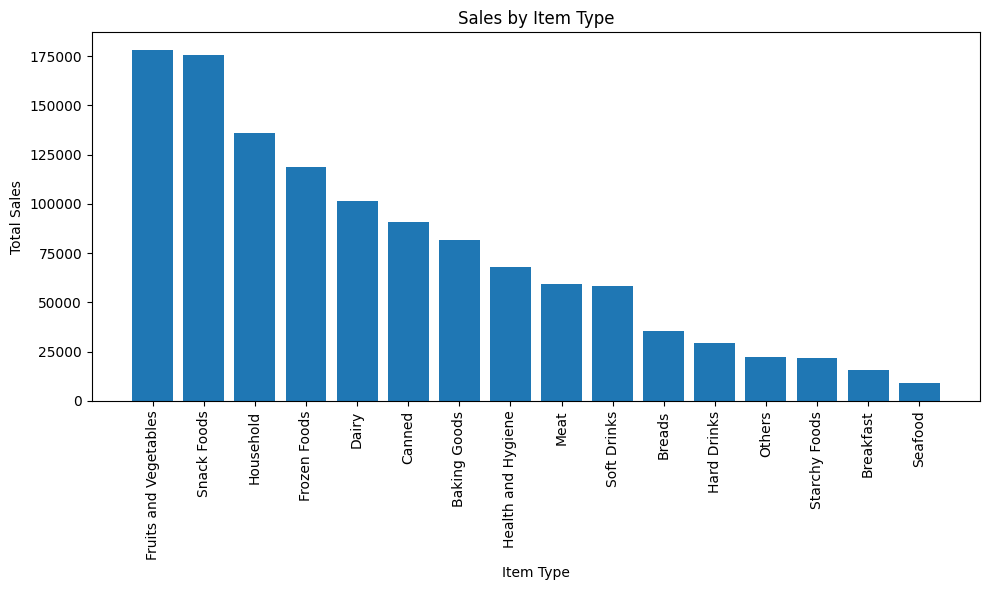

In [17]:
sales_by_fat=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
print(sales_by_fat)
plt.figure(figsize=(10,6))
plt.bar(sales_by_fat.index,sales_by_fat.values)
plt.xticks(rotation=90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Sales by Item Type")
plt.tight_layout()
plt.show()

**fat content by outlet for total sales**

<Figure size 1000x600 with 0 Axes>

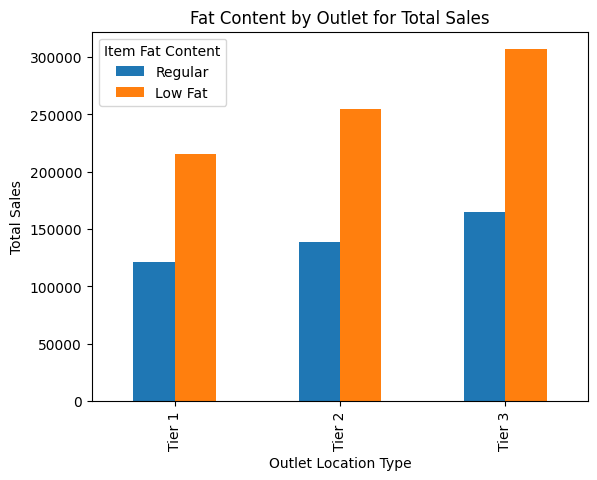

In [19]:
grouped=df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped=grouped[["Regular","Low Fat"]]
plt.figure(figsize=(10,6))
grouped.plot(kind="bar")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.title("Fat Content by Outlet for Total Sales")
plt.show()

**total sales by outlet establishment**

Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Sales, dtype: float64


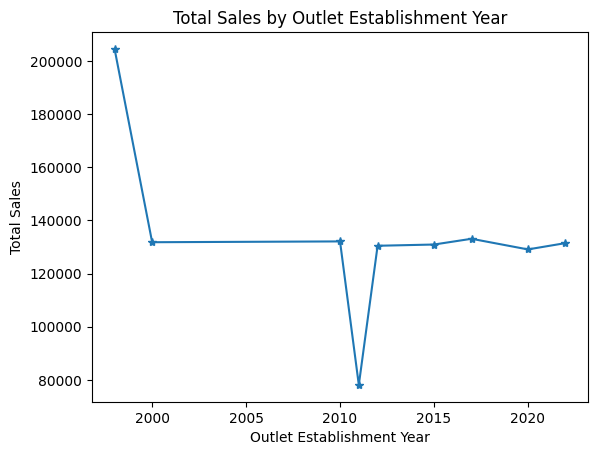

In [21]:
from matplotlib.lines import lineStyles
sales_by_year=df.groupby("Outlet Establishment Year")["Sales"].sum()
print(sales_by_year)
plt.plot(sales_by_year.index,sales_by_year.values,marker='*',linestyle='-')
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Outlet Establishment Year")
plt.show()

**SALES BY OUTLET SIZE**

Outlet Size
High      248991.5840
Medium    507895.7284
Small     444794.1684
Name: Sales, dtype: float64


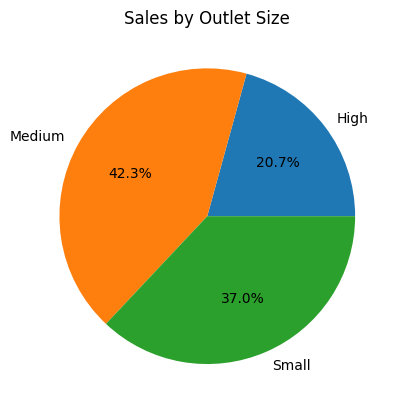

In [23]:
sales_by_size=df.groupby("Outlet Size")["Sales"].sum()
print(sales_by_size)
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%1.1f%%')
plt.title("Sales by Outlet Size")
plt.show()

**SALES BY OUTLET LOCATION**

Outlet Location Type
Tier 3    472133.0272
Tier 2    393150.6416
Tier 1    336397.8120
Name: Sales, dtype: float64


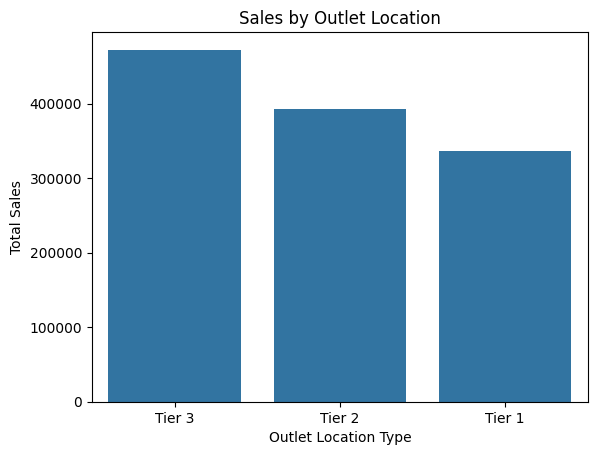

In [25]:
sales_by_location=df.groupby("Outlet Location Type")["Sales"].sum().sort_values(ascending=False)
print(sales_by_location)
sns.barplot(x=sales_by_location.index,y=sales_by_location.values)
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.title("Sales by Outlet Location")
plt.show()